In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import re
import gdown

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import folium
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [ ]:
drive_link = "https://drive.google.com/file/d/1XmAMD0s4kWDwh4yD3ArbLlhKY7vVgGHY/view?usp=sharing"

parquet_path = "weekly_data.parquet"
gdown.download(drive_link, parquet_path, quiet=False, fuzzy=True)

weekly_df_lstm = pd.read_parquet(parquet_path, engine='pyarrow')

csv_path = "weekly_data.csv"
weekly_df_lstm.to_csv(csv_path, index=False)

print(f"Successfully loaded data. Shape: {weekly_df_lstm.shape}")
print("\nLoaded DataFrame columns:")
print(weekly_df_lstm.columns.tolist())
print("\nFirst 5 rows of loaded data:")
print(weekly_df_lstm.head())
print("\nData types:")
weekly_df_lstm.info()


Downloading...
From: https://drive.google.com/uc?id=1XmAMD0s4kWDwh4yD3ArbLlhKY7vVgGHY
To: /content/weekly_data.parquet
100%|██████████| 95.5k/95.5k [00:00<00:00, 55.3MB/s]


Successfully loaded data. Shape: (9752, 10)

Loaded DataFrame columns:
['year', 'week_of_year', 'NEIGHBORHOOD_CLUSTER', 'crime_count', 'crime_count_next_week', 'is_hotspot_next_week', 'crime_count_lag1', 'crime_count_lag4', 'crime_count_roll_mean4', 'crime_count_roll_std4']

First 5 rows of loaded data:
   year  week_of_year NEIGHBORHOOD_CLUSTER  crime_count  \
0  2021             1            Cluster 1            9   
1  2021             2            Cluster 1           17   
2  2021             3            Cluster 1           10   
3  2021             4            Cluster 1            8   
4  2021             5            Cluster 1            7   

   crime_count_next_week  is_hotspot_next_week  crime_count_lag1  \
0                   17.0                     0               NaN   
1                   10.0                     0               9.0   
2                    8.0                     0              17.0   
3                    7.0                     0              10.0   


In [ ]:
print("Preparing data for LSTM (univariate 'crime_count')...")

# Selecting Columns & Handle Target NaNs
print("Selecting columns and handling target NaNs...")
lstm_cols = ['NEIGHBORHOOD_CLUSTER', 'year', 'week_of_year', 'crime_count', 'crime_count_next_week']
model_data_lstm = weekly_df_lstm[lstm_cols].copy()

# Dropping the rows where the target is NaN (last week for each cluster)
rows_before_drop = model_data_lstm.shape[0]
model_data_lstm.dropna(subset=['crime_count_next_week'], inplace=True)
rows_after_drop = model_data_lstm.shape[0]
print(f"Dropped {rows_before_drop - rows_after_drop} rows with NaN target.")
if model_data_lstm.empty:
    print("Error: DataFrame empty after dropping target NaNs.")
    exit()

# Train-Test Split In Chronological order
print("Performing chronological train-test split...")
split_year = 2024
train_df = model_data_lstm[model_data_lstm['year'] < split_year].copy()
test_df = model_data_lstm[model_data_lstm['year'] >= split_year].copy()
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
if train_df.empty or test_df.empty:
    print("Error: Train or test split resulted in empty DataFrame.")
    exit()

# We are using MinMax scaler to Scale Data
# LSTMs are sensitive to scale, so scale crime_count between 0 and 1
print("Scaling 'crime_count' data...")
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshaping it because the scaler expects 2D array [n_samples, n_features]
scaler.fit(train_df[['crime_count']])

# Apply scaler to both train and test data
train_df['scaled_count'] = scaler.transform(train_df[['crime_count']])
test_df['scaled_count'] = scaler.transform(test_df[['crime_count']])



Preparing data for LSTM (univariate 'crime_count')...
Selecting columns and handling target NaNs...
Dropped 46 rows with NaN target.
Performing chronological train-test split...
Train shape: (7314, 5), Test shape: (2392, 5)
Scaling 'crime_count' data...


In [ ]:
# Creating the Input/Output Sequences per Cluster
print("Creating input/output sequences...")
N_PAST_WEEKS = 4 # Number of past weeks, we are using 4

# Helper function for univariate sequences
def create_univariate_sequences(data, n_past):
    X, y = [], []
    for i in range(n_past, len(data)):

        X.append(data[i - n_past:i])

        y.append(data[i])
    return np.array(X), np.array(y)

all_X_train_seq, all_y_train_seq = [], []
all_X_test_seq, all_y_test_seq = [], []

unique_clusters_lstm = model_data_lstm['NEIGHBORHOOD_CLUSTER'].unique()

for cluster in unique_clusters_lstm:
    print(f"Processing cluster: {cluster}")
    train_cluster_scaled = train_df[train_df['NEIGHBORHOOD_CLUSTER'] == cluster]['scaled_count'].values
    test_cluster_scaled = test_df[test_df['NEIGHBORHOOD_CLUSTER'] == cluster]['scaled_count'].values

    # Create sequences if enough data exists
    if len(train_cluster_scaled) >= N_PAST_WEEKS + 1:
        X_train_c, y_train_c = create_univariate_sequences(train_cluster_scaled, N_PAST_WEEKS)
        all_X_train_seq.append(X_train_c)
        all_y_train_seq.append(y_train_c)

    if len(test_cluster_scaled) >= N_PAST_WEEKS + 1:
        X_test_c, y_test_c = create_univariate_sequences(test_cluster_scaled, N_PAST_WEEKS)
        all_X_test_seq.append(X_test_c)
        all_y_test_seq.append(y_test_c)

# Combine Sequences from All Clusters
if not all_X_train_seq:
    print("Error: No training sequences generated.")
    exit()
else:
    X_train_lstm = np.concatenate(all_X_train_seq, axis=0)
    y_train_lstm = np.concatenate(all_y_train_seq, axis=0)
    X_test_lstm = np.concatenate(all_X_test_seq, axis=0)
    y_test_lstm = np.concatenate(all_y_test_seq, axis=0)

    # Reshaping for LSTM Input: [samples, timesteps, features]
    print("Reshaping data for LSTM input...")
    n_features = 1
    X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], n_features))
    X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], n_features))

    print("\n--- Data preparation for LSTM complete ---")
    print(f"Using N_PAST_WEEKS = {N_PAST_WEEKS}")
    print(f"X_train_lstm shape: {X_train_lstm.shape}")
    print(f"y_train_lstm shape: {y_train_lstm.shape}")
    print(f"X_test_lstm shape: {X_test_lstm.shape}")
    print(f"y_test_lstm shape: {y_test_lstm.shape}")


Creating input/output sequences...
Processing cluster: Cluster 1
Processing cluster: Cluster 10
Processing cluster: Cluster 11
Processing cluster: Cluster 12
Processing cluster: Cluster 13
Processing cluster: Cluster 14
Processing cluster: Cluster 15
Processing cluster: Cluster 16
Processing cluster: Cluster 17
Processing cluster: Cluster 18
Processing cluster: Cluster 19
Processing cluster: Cluster 2
Processing cluster: Cluster 20
Processing cluster: Cluster 21
Processing cluster: Cluster 22
Processing cluster: Cluster 23
Processing cluster: Cluster 24
Processing cluster: Cluster 25
Processing cluster: Cluster 26
Processing cluster: Cluster 27
Processing cluster: Cluster 28
Processing cluster: Cluster 29
Processing cluster: Cluster 3
Processing cluster: Cluster 30
Processing cluster: Cluster 31
Processing cluster: Cluster 32
Processing cluster: Cluster 33
Processing cluster: Cluster 34
Processing cluster: Cluster 35
Processing cluster: Cluster 36
Processing cluster: Cluster 37
Process

In [ ]:
N_PAST_WEEKS = 4  # Number of timesteps in each input sequence
n_features = 1   # Number of features used at each timestep (just scaled_count for now)

print("--- Defining LSTM Model Architecture ---")

# 1. Build the Model
model = Sequential(name="LSTM_Crime_Forecaster")
model.add(LSTM(
    units=50,                # Number of LSTM units/neurons in the layer
    activation='relu',       # Activation function (relu or tanh are common)
    input_shape=(N_PAST_WEEKS, n_features) # Defines expected input shape: (timesteps, features)
    # return_sequences=True # Only if stacking LSTM layers
))
# Optional: Add Dropout for regularization (helps prevent overfitting)
model.add(Dropout(0.2))
# Output Layer: Dense layer with 1 unit (predicting one value: next week's scaled count)
# Linear activation is typical for regression outputs
model.add(Dense(units=1, activation='linear'))

# 2. Compile the Model
print("Compiling the model...")
# Optimizer: 'adam' is a good default choice
# Loss function: 'mean_squared_error' (MSE) is standard for regression
model.compile(optimizer='adam', loss='mean_squared_error')

# Print model summary
print("\nModel Summary:")
model.summary()

# 3. Train the Model
print("\n--- Training the LSTM Model ---")

# Optional: Define Early Stopping to prevent overfitting
# Monitors 'val_loss' and stops if it doesn't improve for 'patience' epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define training parameters
EPOCHS = 50       # Number of passes through the training data (adjust as needed)
BATCH_SIZE = 32   # Number of samples per gradient update

# Train the model using .fit()
# Provide validation data (X_test_lstm, y_test_lstm) to monitor performance on unseen data
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stopping], # Add early stopping callback
    verbose=1 # Set to 1 or 2 to see training progress per epoch, 0 for silent
)

print("\nModel Training Complete")

# You can optionally plot training history (loss vs epochs)
# import matplotlib.pyplot as plt
# plt.plot(history.history['loss'], label='Training Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.title('Model Loss During Training')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.show()

--- Defining LSTM Model Architecture ---
Compiling the model...

Model Summary:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_Crime_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the LSTM Model ---
Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0135 - val_loss: 0.0031
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0042 - val_loss: 0.0031
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0043 - val_loss: 0.0032
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - val_loss: 0.0031
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042 - val_loss: 0.0031
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - val_loss: 0.0031
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - val_loss: 0.0031
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - val_loss: 0.0031
Epoch 9/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 10/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 11/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0038 - val_loss: 0.0031
Epoch 12/50
223/223

Evaluating the LSTM Model Performance
Making predictions on X_test_lstm...
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions complete.
Inverse transforming predictions and actual test values to original scale...
Inverse transformation complete.

--- Performance Metrics (Original Scale) ---
Mean Absolute Error (MAE): 3.2391 crimes
Mean Squared Error (MSE): 22.4105
Root Mean Squared Error (RMSE): 4.7340 crimes
R-squared (R2 Score): 0.8225


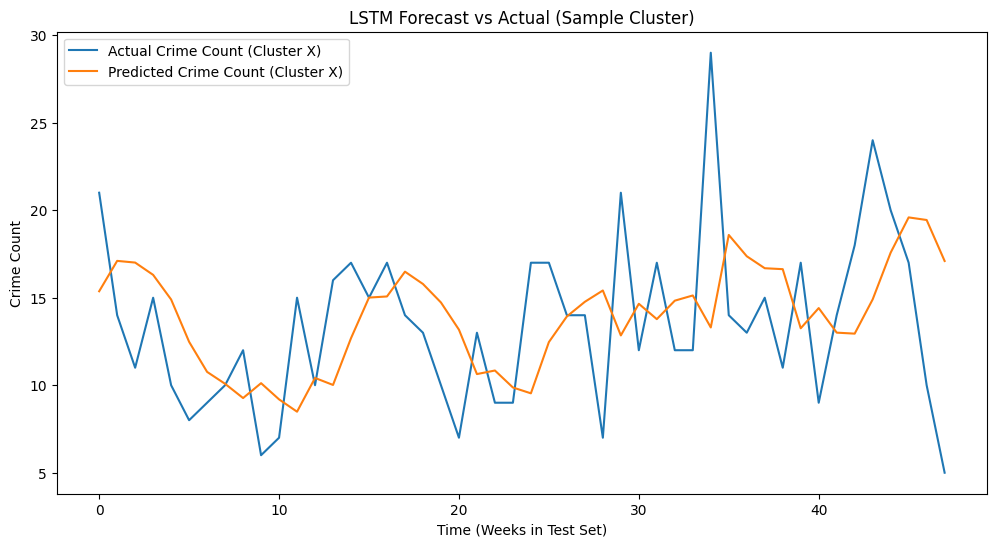

In [ ]:
print("Evaluating the LSTM Model Performance")

# Make predictions on the test set
print("Making predictions on X_test_lstm...")
y_pred_scaled_lstm = model.predict(X_test_lstm)
print("Predictions complete.")

# Inverse transform to original scale
print("Inverse transforming predictions and actual test values to original scale...")
y_pred_lstm_orig_scale = scaler.inverse_transform(y_pred_scaled_lstm)
y_test_lstm_orig_scale = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
print("Inverse transformation complete.")

# Calculate Evaluation Metrics on the Original Scale
print("\n--- Performance Metrics (Original Scale) ---")
mae_lstm  = mean_absolute_error(y_test_lstm_orig_scale, y_pred_lstm_orig_scale)
mse_lstm  = mean_squared_error(y_test_lstm_orig_scale, y_pred_lstm_orig_scale)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm  = r2_score(y_test_lstm_orig_scale, y_pred_lstm_orig_scale)

print(f"Mean Absolute Error (MAE): {mae_lstm:.4f} crimes")
print(f"Mean Squared Error (MSE): {mse_lstm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f} crimes")
print(f"R-squared (R2 Score): {r2_lstm:.4f}")

# Plot forecast vs actual for a sample cluster
num_test_sequences_first_cluster = X_test_lstm[
    test_df[test_df['NEIGHBORHOOD_CLUSTER'] == unique_clusters_lstm[0]].index[:len(X_test_c)]
].shape[0]

plt.figure(figsize=(12,6))
plt.plot(y_test_lstm_orig_scale[:num_test_sequences_first_cluster], label='Actual Crime Count (Cluster X)')
plt.plot(y_pred_lstm_orig_scale[:num_test_sequences_first_cluster], label='Predicted Crime Count (Cluster X)')
plt.title('LSTM Forecast vs Actual (Sample Cluster)')
plt.xlabel('Time (Weeks in Test Set)')
plt.ylabel('Crime Count')
plt.legend()
plt.show()
